## 1. Imports & Device

In [1]:
import os
import gc
import random
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pathlib import Path
import sys; sys.path.append('..')  # so `src/` is importable from notebooks/
from src.models import HSI_UNet, Original_UNet
from src.dataset import SatelliteDataset, get_loaders
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, jaccard_score, classification_report, confusion_matrix
from matplotlib import colors as mcolors
import matplotlib.pyplot as plt



os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
if torch.cuda.is_available():
    torch.cuda.empty_cache()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2. Global Config

In [2]:
NUM_CLASSES  = 4       # 0: Background  1: Severe  2: Moderate  3: Healthy
BATCH_SIZE   = 16
NUM_EPOCHS   = 200
PEAK_LR      = 2e-4
WEIGHT_DECAY = 0.01
PLATEAU_PATIENCE = 8
PLATEAU_FACTOR   = 0.5

ROOT_DIR          = Path(r'C:\Users\Achilleas\Desktop')
DATASET_BASE_NAME = "Balanced_New_Health_Dataset"

SCENARIO_CONFIG = {
    0: {"bands": 200, "name": "Baseline"},
    1: {"bands": 183, "name": "NDVI_Core"},
    2: {"bands": 170, "name": "Plus_Green"},
    3: {"bands": 153, "name": "Plus_RedEdge"},
    4: {"bands": 140, "name": "Plus_Blue"},
    5: {"bands":  77, "name": "Plus_ExtNIR"},
    6: {"bands":  31, "name": "Extreme_Green"},
    7: {"bands":   3, "name": "True_RGB"},
    8: {"bands":   4, "name": "RGB_NIR"},
}

# Class weights derived from inverse pixel frequency on the training set
# Formula: w_c = total_pixels / (num_classes * count_c), normalised so min = 1.0
CLASS_WEIGHTS = torch.tensor([2.098, 3.6245, 4.5503, 1.0]).to(DEVICE)

print("Config loaded.")

Config loaded.


## 3. Dataset

In [ ]:
# SatelliteDataset and get_loaders are now defined in src/dataset.py
# (imported above) so they can be reused outside this notebook.
print("SatelliteDataset and get_loaders imported from src/dataset.py")

## 4. Model Definitions

In [ ]:
# HSI_UNet and Original_UNet are now defined in src/models.py
# (imported above) so they can be reused outside this notebook.
print("HSI_UNet and Original_UNet imported from src/models.py")

## 5. Training — All Models, All Scenarios

In [ ]:
SELECTED_LEVELS    = [0, 1, 2, 3, 4, 5, 6, 7, 8]
MODELS_TO_COMPARE  = ["HSI_UNet", "Original_UNet"]

all_run_summaries = []
all_run_histories = {}

criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

for model_name in MODELS_TO_COMPARE:
    for level in SELECTED_LEVELS:
        hist_key = f"{model_name}_L{level}"
        all_run_histories[hist_key] = {'train_loss': [], 'val_loss': [], 'val_acc': []}

        n_bands = SCENARIO_CONFIG[level]["bands"]
        print(f"\n{'='*65}")
        print(f"  {model_name} | Level {level} | {n_bands} bands | {NUM_EPOCHS} epochs")
        print(f"{'='*65}")

        train_loader, val_loader, _ = get_loaders(ROOT_DIR, DATASET_BASE_NAME, level, NUM_CLASSES, BATCH_SIZE)

        model     = (HSI_UNet if model_name == "HSI_UNet" else Original_UNet)(
                        in_channels=n_bands, num_classes=NUM_CLASSES).to(DEVICE)
        optimizer = optim.AdamW(model.parameters(), lr=PEAK_LR, weight_decay=WEIGHT_DECAY)
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=PLATEAU_FACTOR,
                                      patience=PLATEAU_PATIENCE)

        best_val_loss = float('inf')
        best_val_acc  = 0.0
        best_epoch    = 0

        for epoch in range(1, NUM_EPOCHS + 1):
            # Train
            model.train()
            t_loss = 0.0
            for imgs, msks in tqdm(train_loader, desc=f"L{level} {model_name} Ep{epoch}", leave=False):
                imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(imgs), msks.long())
                loss.backward()
                optimizer.step()
                t_loss += loss.item()

            # Validate
            model.eval()
            v_loss, corr, tot = 0.0, 0, 0
            with torch.no_grad():
                for imgs, msks in val_loader:
                    imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)
                    out    = model(imgs)
                    v_loss += criterion(out, msks.long()).item()
                    preds   = torch.argmax(out, dim=1)
                    corr   += (preds == msks).sum().item()
                    tot    += msks.numel()

            avg_t = t_loss / len(train_loader)
            avg_v = v_loss / len(val_loader)
            acc   = 100.0 * corr / tot

            scheduler.step(avg_v)

            all_run_histories[hist_key]['train_loss'].append(avg_t)
            all_run_histories[hist_key]['val_loss'].append(avg_v)
            all_run_histories[hist_key]['val_acc'].append(acc)

            if avg_v < best_val_loss:
                best_val_loss = avg_v
                best_val_acc  = acc
                best_epoch    = epoch
                torch.save(model.state_dict(), f"BEST_MODEL_{model_name}_L{level}.pth")

            if epoch % 50 == 0 or epoch == 1:
                print(f"  Ep {epoch:3d}/{NUM_EPOCHS} | "
                      f"Train {avg_t:.4f} | Val {avg_v:.4f} | Acc {acc:.2f}% | "
                      f"Best {best_val_acc:.2f}% @ ep{best_epoch}")

        all_run_summaries.append({
            'Model':      model_name,
            'Level':      f"L{level}",
            'Bands':      n_bands,
            'Best_Epoch': best_epoch,
            'Best_Val_Loss': round(best_val_loss, 4),
            'Best_Val_Acc':  round(best_val_acc, 2),
        })

        del model, optimizer, train_loader, val_loader
        torch.cuda.empty_cache()
        gc.collect()

# Save histories for later plotting
with open('all_run_histories.pkl', 'wb') as f:
    pickle.dump(all_run_histories, f)

df_summary = pd.DataFrame(all_run_summaries)
print("\n" + "="*65)
print("ALL SCENARIOS COMPLETE")
print("="*65)
print(df_summary.to_string(index=False))
df_summary.to_csv("training_summary.csv", index=False)
print("\nHistories saved to: all_run_histories.pkl")
print("Summary saved to:   training_summary.csv")

Saved: pred_L0.png


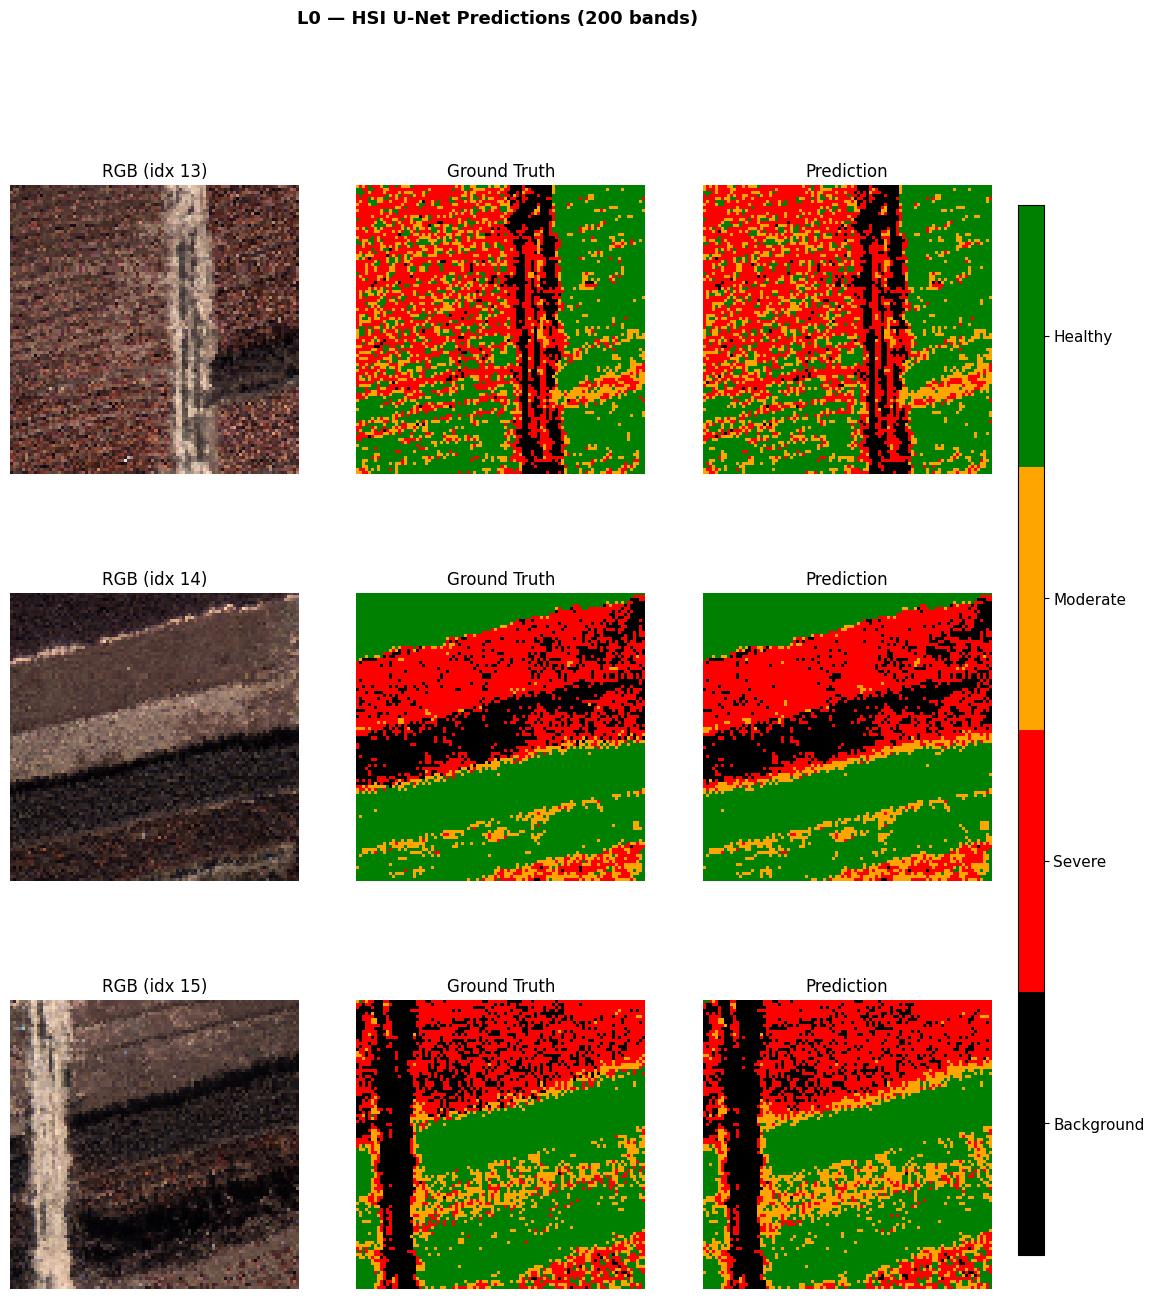

Saved: pred_L5.png


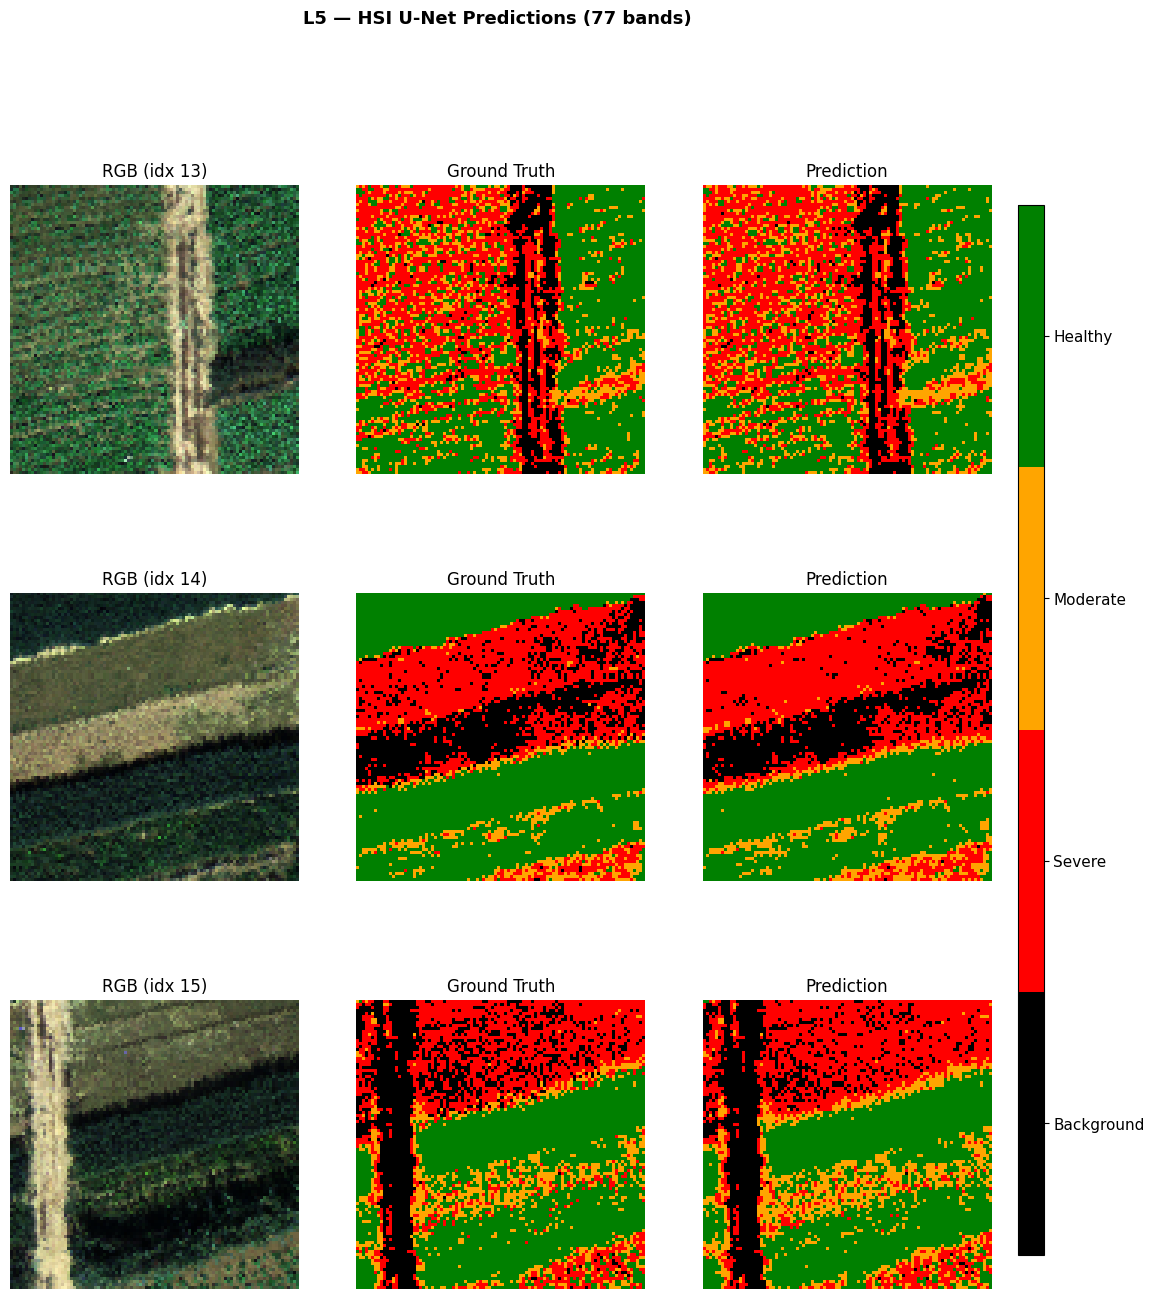

Saved: pred_L6.png


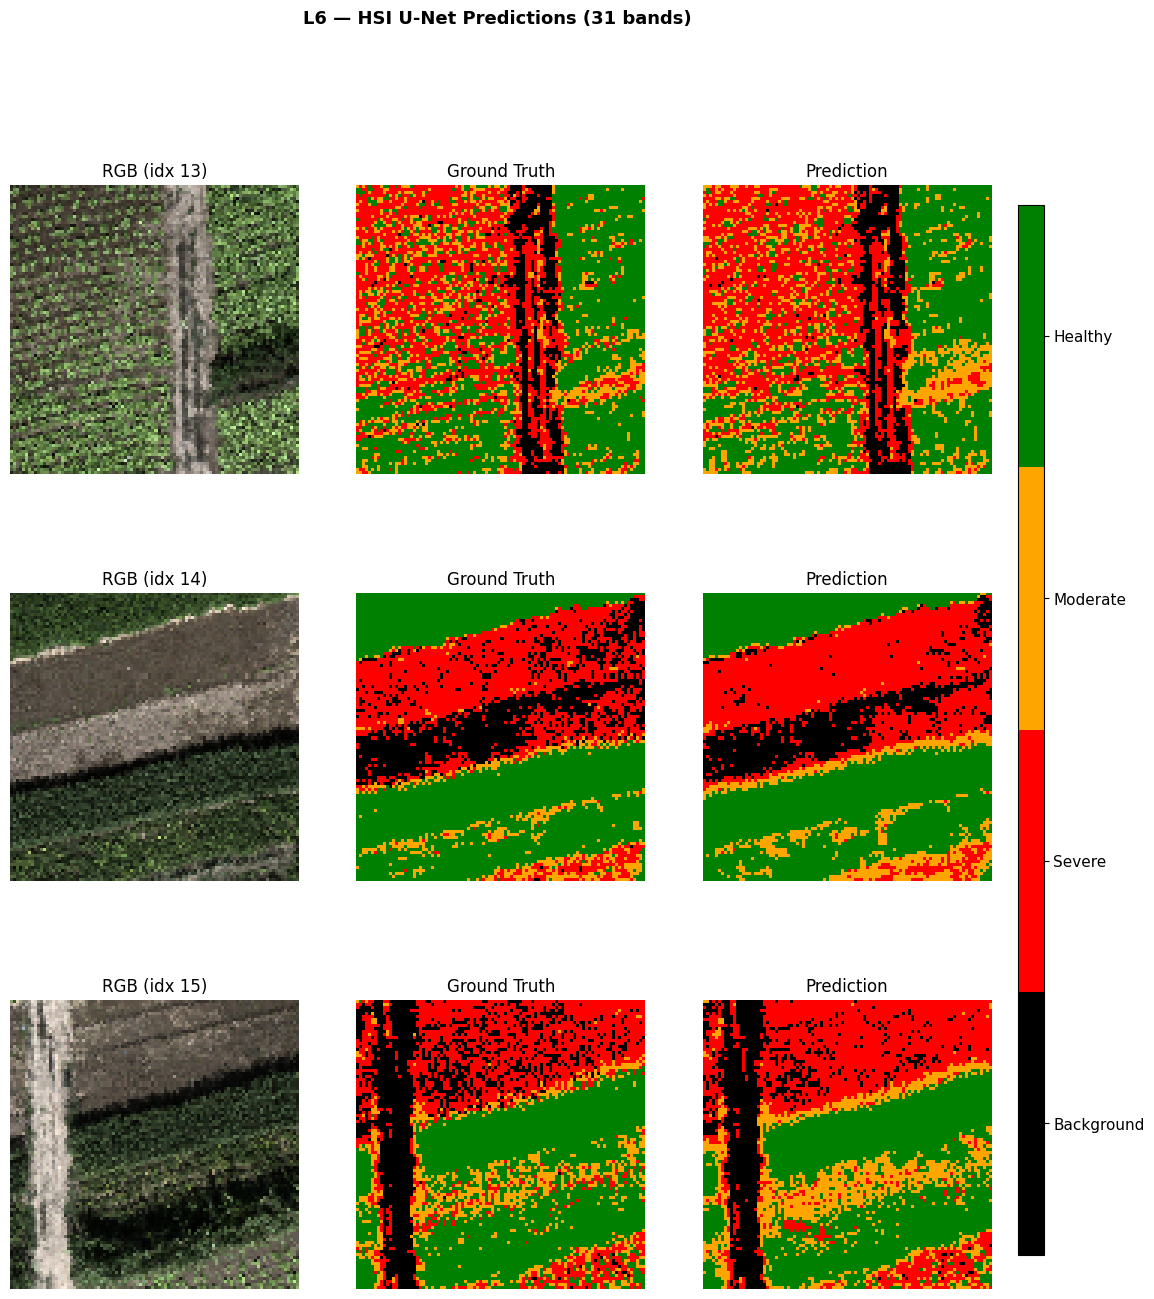

Saved: pred_L7.png


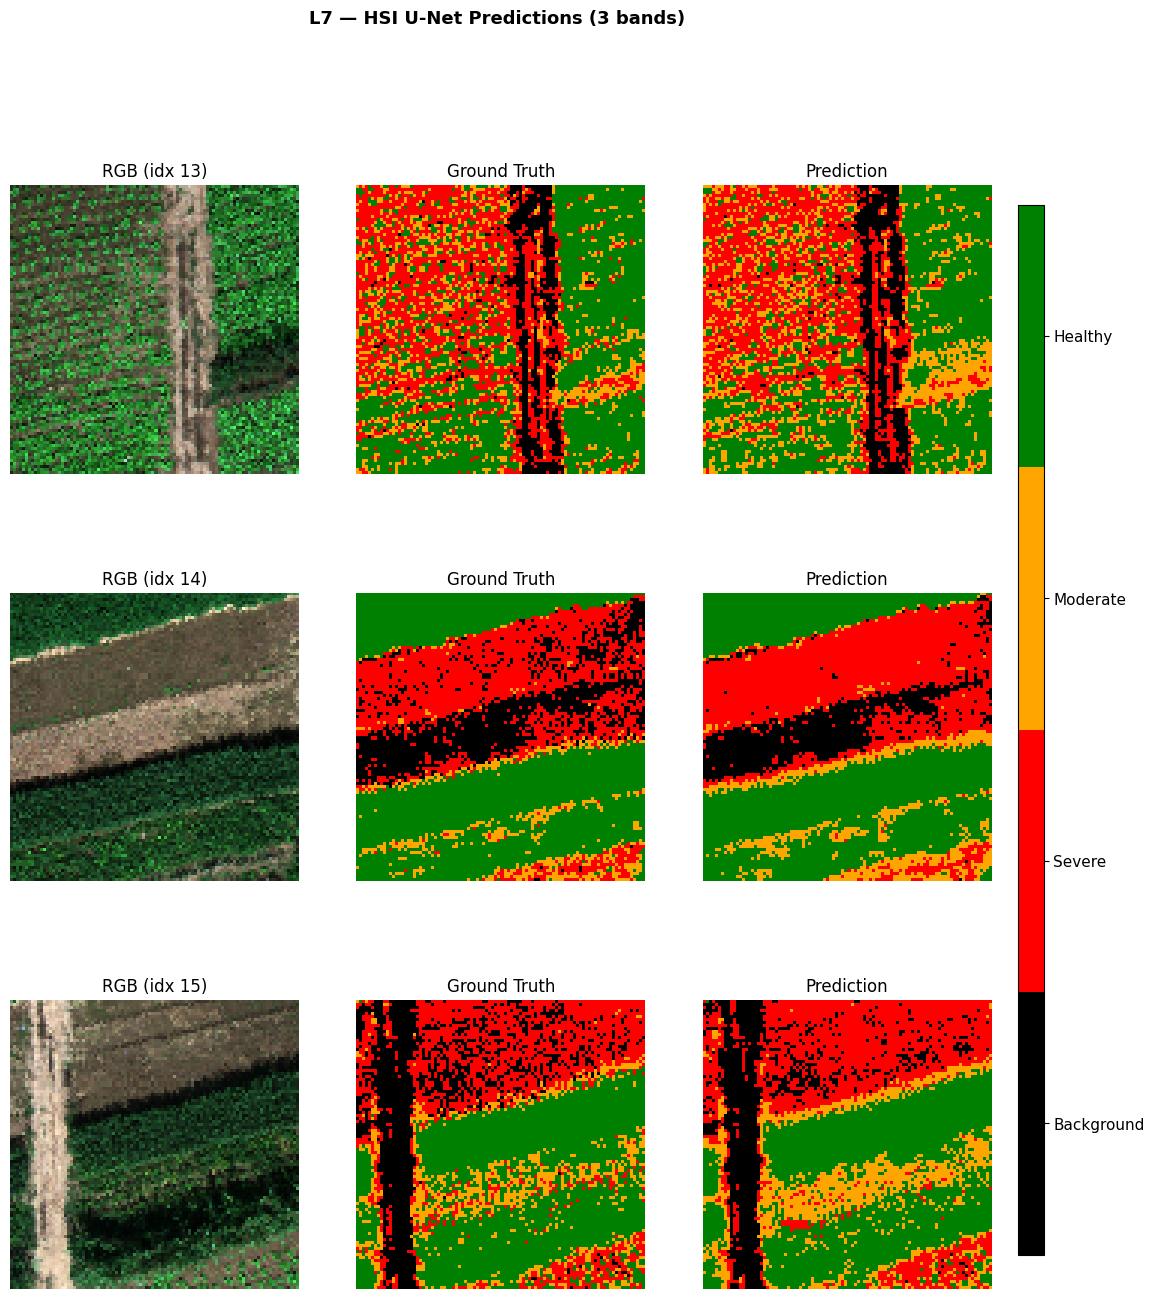

Saved: pred_L8.png


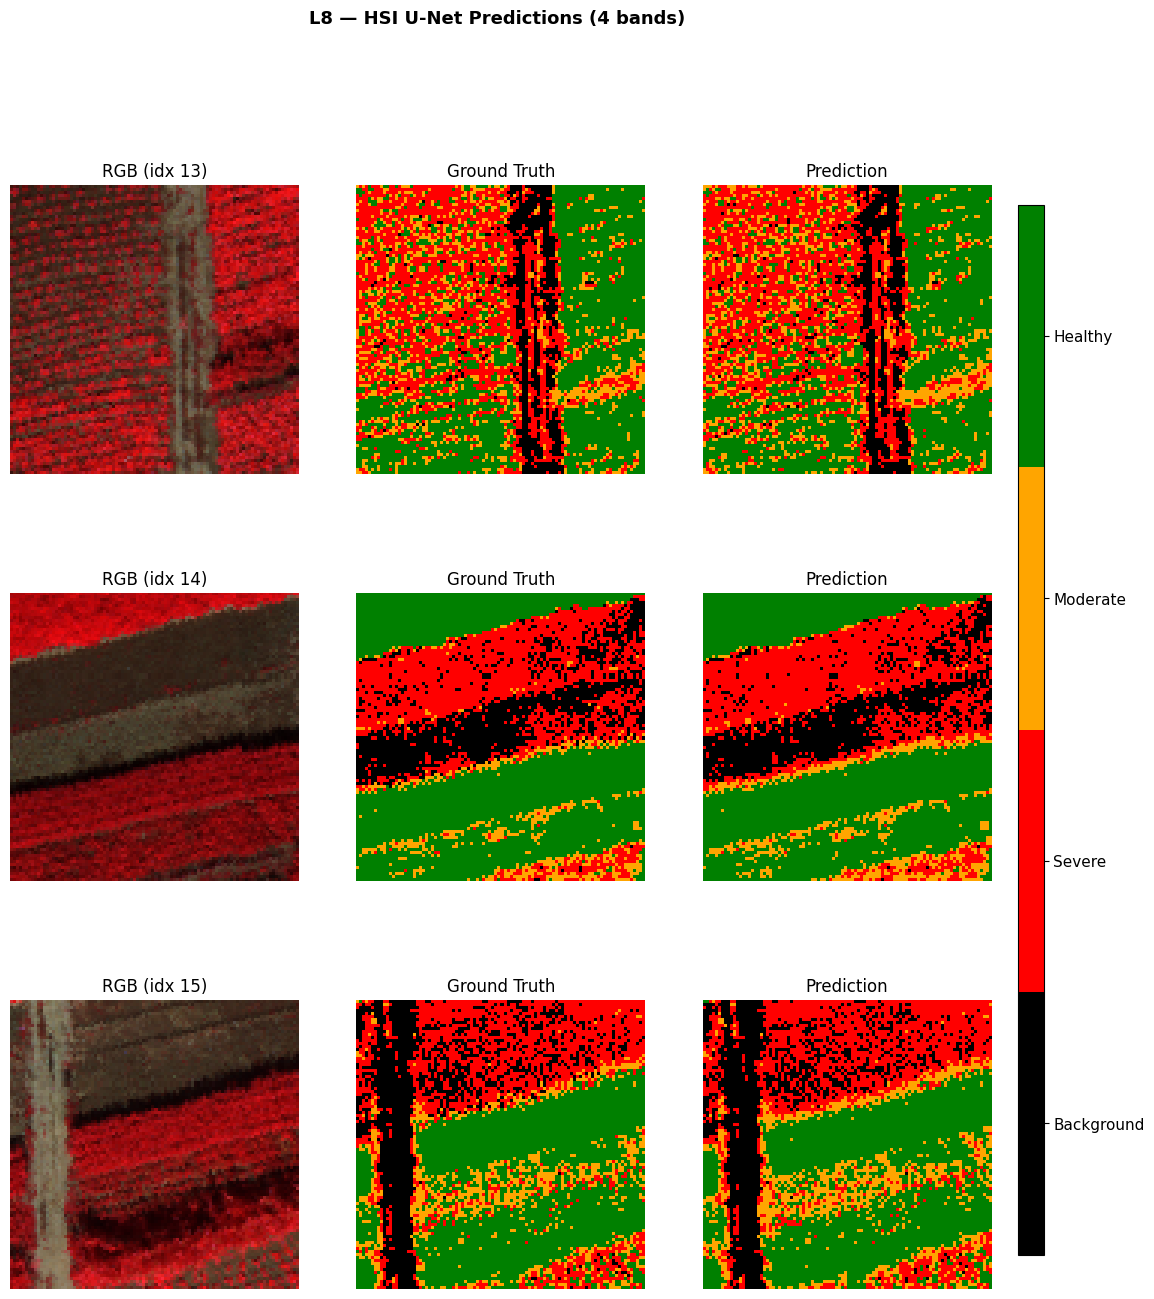

In [16]:
def visualize_predictions(data_root, level, indices=[12, 25, 40], save_path=None):
    device  = DEVICE
    n_bands = SCENARIO_CONFIG[level]["bands"]
    
    # Load model
    model_path = f"BEST_MODEL_HSI_UNet_L{level}.pth"
    mdl = HSI_UNet(in_channels=n_bands, num_classes=NUM_CLASSES).to(device)
    mdl.load_state_dict(torch.load(model_path, map_location=device))
    mdl.eval()

    rs_files = sorted((Path(ROOT_DIR) / f"{DATASET_BASE_NAME}_L{level}" / "Test" / "rs").glob('*.npy'))

    cmap = mcolors.ListedColormap(['black', 'red', 'orange', 'green'])
    norm = mcolors.BoundaryNorm(np.arange(-0.5, NUM_CLASSES, 1), cmap.N)

    indices = [i for i in indices if i < len(rs_files)]
    fig, axes = plt.subplots(len(indices), 3, figsize=(13, 5 * len(indices)))
    if len(indices) == 1: axes = axes[np.newaxis, :]

    fig.suptitle(f'L{level} — HSI U-Net Predictions ({n_bands} bands)',
                 fontsize=13, fontweight='bold')

    for row, idx in enumerate(indices):
        rs_np   = np.nan_to_num(np.load(rs_files[idx]).astype(np.float32))
        bands_n = rs_np.shape[-1]
        r = min(int(bands_n * 0.8), bands_n-1)
        g = min(int(bands_n * 0.5), bands_n-1)
        b = min(int(bands_n * 0.2), bands_n-1)
        if bands_n >= 200: r, g, b = 62, 38, 16
        rgb = np.stack([rs_np[:,:,r], rs_np[:,:,g], rs_np[:,:,b]], axis=-1)
        rgb = np.clip((rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8), 0, 1)
        gt_path = rs_files[idx].parent.parent / 'gt' / rs_files[idx].name
        gt   = np.clip(np.round(np.load(gt_path)).astype(np.int64), 0, NUM_CLASSES-1)
        inp  = torch.from_numpy(rs_np).permute(2,0,1).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = torch.argmax(mdl(inp), dim=1).squeeze().cpu().numpy()
        axes[row,0].imshow(rgb);                        axes[row,0].set_title(f"RGB (idx {idx})")
        axes[row,1].imshow(gt,   cmap=cmap, norm=norm); axes[row,1].set_title("Ground Truth")
        axes[row,2].imshow(pred, cmap=cmap, norm=norm); axes[row,2].set_title("Prediction")
        for ax in axes[row]: ax.axis('off')

    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                        cax=cbar_ax, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(['Background', 'Severe', 'Moderate', 'Healthy'], fontsize=11)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {save_path}")
    plt.show()

# Call for each level
for level in [0, 5, 6, 7, 8]:
    visualize_predictions(
        data_root = ROOT_DIR / f"{DATASET_BASE_NAME}_L{level}" / "Test",
        level     = level,
        indices   = [13, 14, 15],
        save_path = f'pred_L{level}.png'
    )

## 6. Evaluation — All Models, All Scenarios

In [5]:
SELECTED_LEVELS   = [0, 1, 2, 3, 4, 5, 6, 7, 8]
MODELS_TO_COMPARE = ["HSI_UNet", "Original_UNet"]

final_table_data = []

for level in SELECTED_LEVELS:
    n_bands = SCENARIO_CONFIG[level]["bands"]
    _, _, test_loader = get_loaders(ROOT_DIR, DATASET_BASE_NAME, level, NUM_CLASSES, BATCH_SIZE)

    for model_name in MODELS_TO_COMPARE:
        weight_file = f"BEST_MODEL_{model_name}_L{level}.pth"

        if not Path(weight_file).exists():
            print(f"  Skipping {weight_file} (not found)")
            continue

        model_class = HSI_UNet if model_name == "HSI_UNet" else Original_UNet
        model = model_class(in_channels=n_bands, num_classes=NUM_CLASSES).to(DEVICE)
        model.load_state_dict(torch.load(weight_file, map_location=DEVICE))
        model.eval()

        y_true_list, y_pred_list = [], []
        with torch.no_grad():
            for imgs, msks in tqdm(test_loader, desc=f"Eval L{level} {model_name}", leave=False):
                imgs = imgs.to(DEVICE)
                pred = torch.argmax(model(imgs), dim=1)
                y_pred_list.append(pred.cpu().numpy().flatten())
                y_true_list.append(msks.numpy().flatten())

        y_true = np.concatenate(y_true_list)
        y_pred = np.concatenate(y_pred_list)

        f1_per_class = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2, 3], zero_division=0)
        f1_macro     = f1_score(y_true, y_pred, average='macro', labels=[0, 1, 2, 3], zero_division=0)
        miou         = jaccard_score(y_true, y_pred, average='macro', labels=[0, 1, 2, 3])
        oa           = 100.0 * (y_pred == y_true).mean()

        final_table_data.append({
            'Level':    f"L{level}",
            'Model':    model_name,
            'Bands':    n_bands,
            'OA (%)':   round(oa, 2),
            'mIoU':     round(miou, 4),
            'F1_macro': round(f1_macro, 4),
            'F1_Bg':    round(f1_per_class[0], 4),
            'F1_Sev':   round(f1_per_class[1], 4),
            'F1_Mod':   round(f1_per_class[2], 4),
            'F1_Hlth':  round(f1_per_class[3], 4),
        })

        del model
        gc.collect()
        torch.cuda.empty_cache()

df_final = pd.DataFrame(final_table_data)
df_final['_lvl'] = df_final['Level'].str.extract(r'(\d+)').astype(int)
df_final = df_final.sort_values(['_lvl', 'Model'], ascending=[True, False]).drop(columns=['_lvl'])

print("\n" + "="*130)
print("FINAL TEST RESULTS — ALL 9 LEVELS x 2 MODELS")
print("="*130)
print(df_final.to_string(index=False))
print("="*130)

df_final.to_csv("Final_Thesis_Comparison_Table_Full.csv", index=False)
print("\nResults saved to: Final_Thesis_Comparison_Table_Full.csv")

Eval L0 HSI_UNet:   0%|          | 0/4 [00:00<?, ?it/s]

Eval L0 Original_UNet:   0%|          | 0/4 [00:00<?, ?it/s]

Eval L1 HSI_UNet:   0%|          | 0/4 [00:00<?, ?it/s]

Eval L1 Original_UNet:   0%|          | 0/4 [00:00<?, ?it/s]

Eval L2 HSI_UNet:   0%|          | 0/4 [00:00<?, ?it/s]

...

Eval L7 HSI_UNet:   0%|          | 0/4 [00:00<?, ?it/s]

Eval L7 Original_UNet:   0%|          | 0/4 [00:00<?, ?it/s]

Eval L8 HSI_UNet:   0%|          | 0/4 [00:00<?, ?it/s]

Eval L8 Original_UNet:   0%|          | 0/4 [00:00<?, ?it/s]


FINAL TEST RESULTS — ALL 9 LEVELS x 2 MODELS
Level         Model  Bands  OA (%)   mIoU  F1_macro  F1_Bg  F1_Sev  F1_Mod  F1_Hlth
   L0 Original_UNet    200   92.14 0.8038    0.8852 0.9658  0.8362  0.7755   0.9634
   L0      HSI_UNet    200   93.79 0.8389    0.9087 0.9696  0.8672  0.8271   0.9710
   L1 Original_UNet    183   92.17 0.8012    0.8834 0.9629  0.8308  0.7736   0.9665
   L1      HSI_UNet    183   93.31 0.8279    0.9017 0.9645  0.8543  0.8172   0.9710
   L2 Original_UNet    170   91.80 0.7932    0.8779 0.9613  0.8202  0.7648   0.9654
   L2      HSI_UNet    170   92.34 0.8082    0.8886 0.9631  0.8415  0.7860   0.9638
   L3 Original_UNet    153   91.15 0.7850    0.8726 0.9589  0.8244  0.7503   0.9570
   L3      HSI_UNet    153   92.79 0.8168    0.8945 0.9624  0.8454  0.8027   0.9675
   L4 Original_UNet    140   91.69 0.7933    0.8782 0.9616  0.8255  0.7642   0.9617
   L4      HSI_UNet    140   92.84 0.8188    0.8959 0.9628  0.8479  0.8058   0.9672
   L5 Original_UNet     77   9

## 7. Comparison Curves

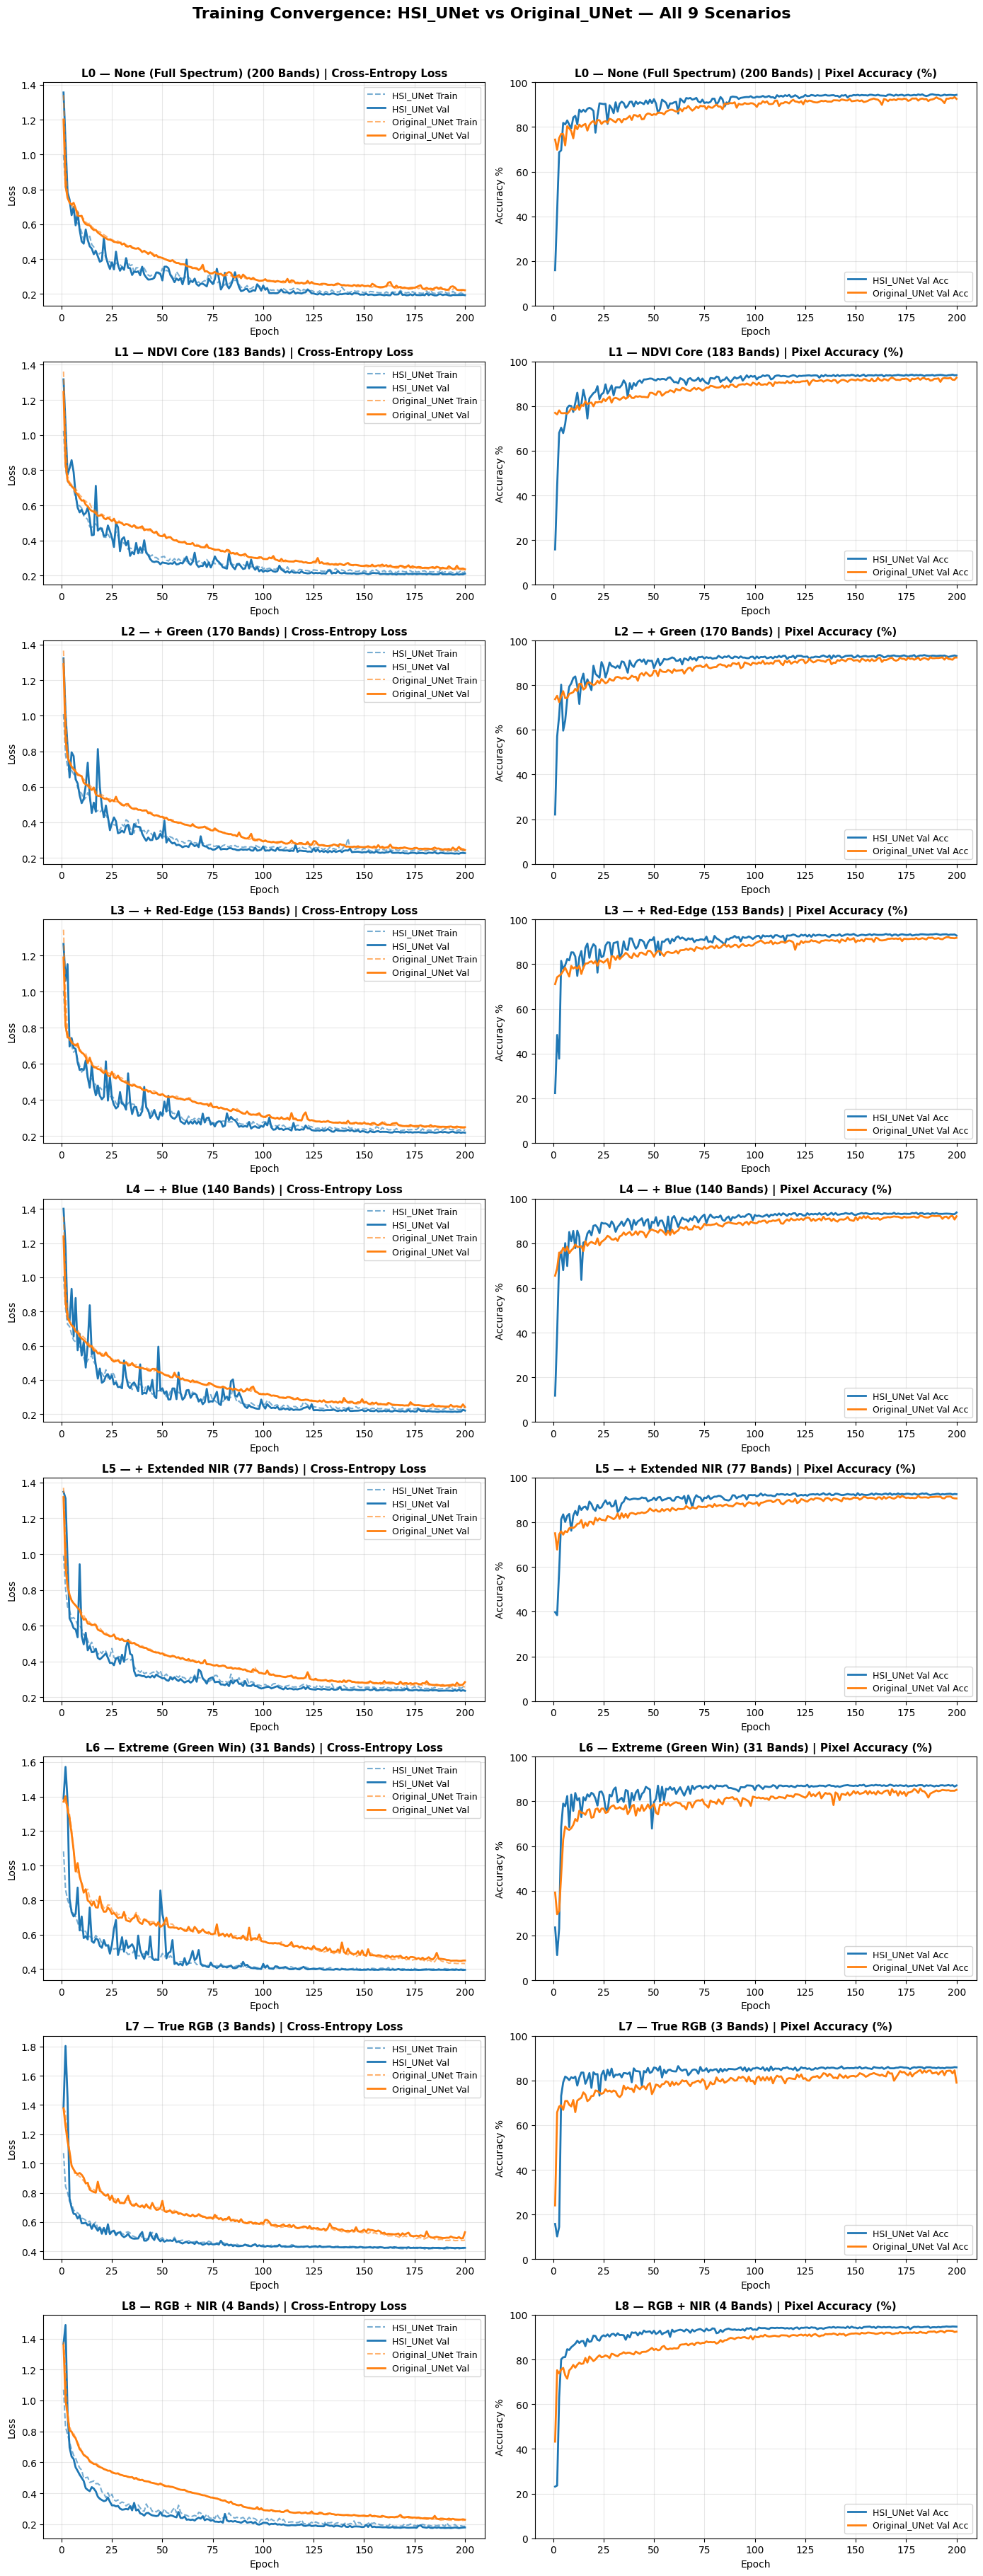

✅ Saved: model_comparison_curves.png


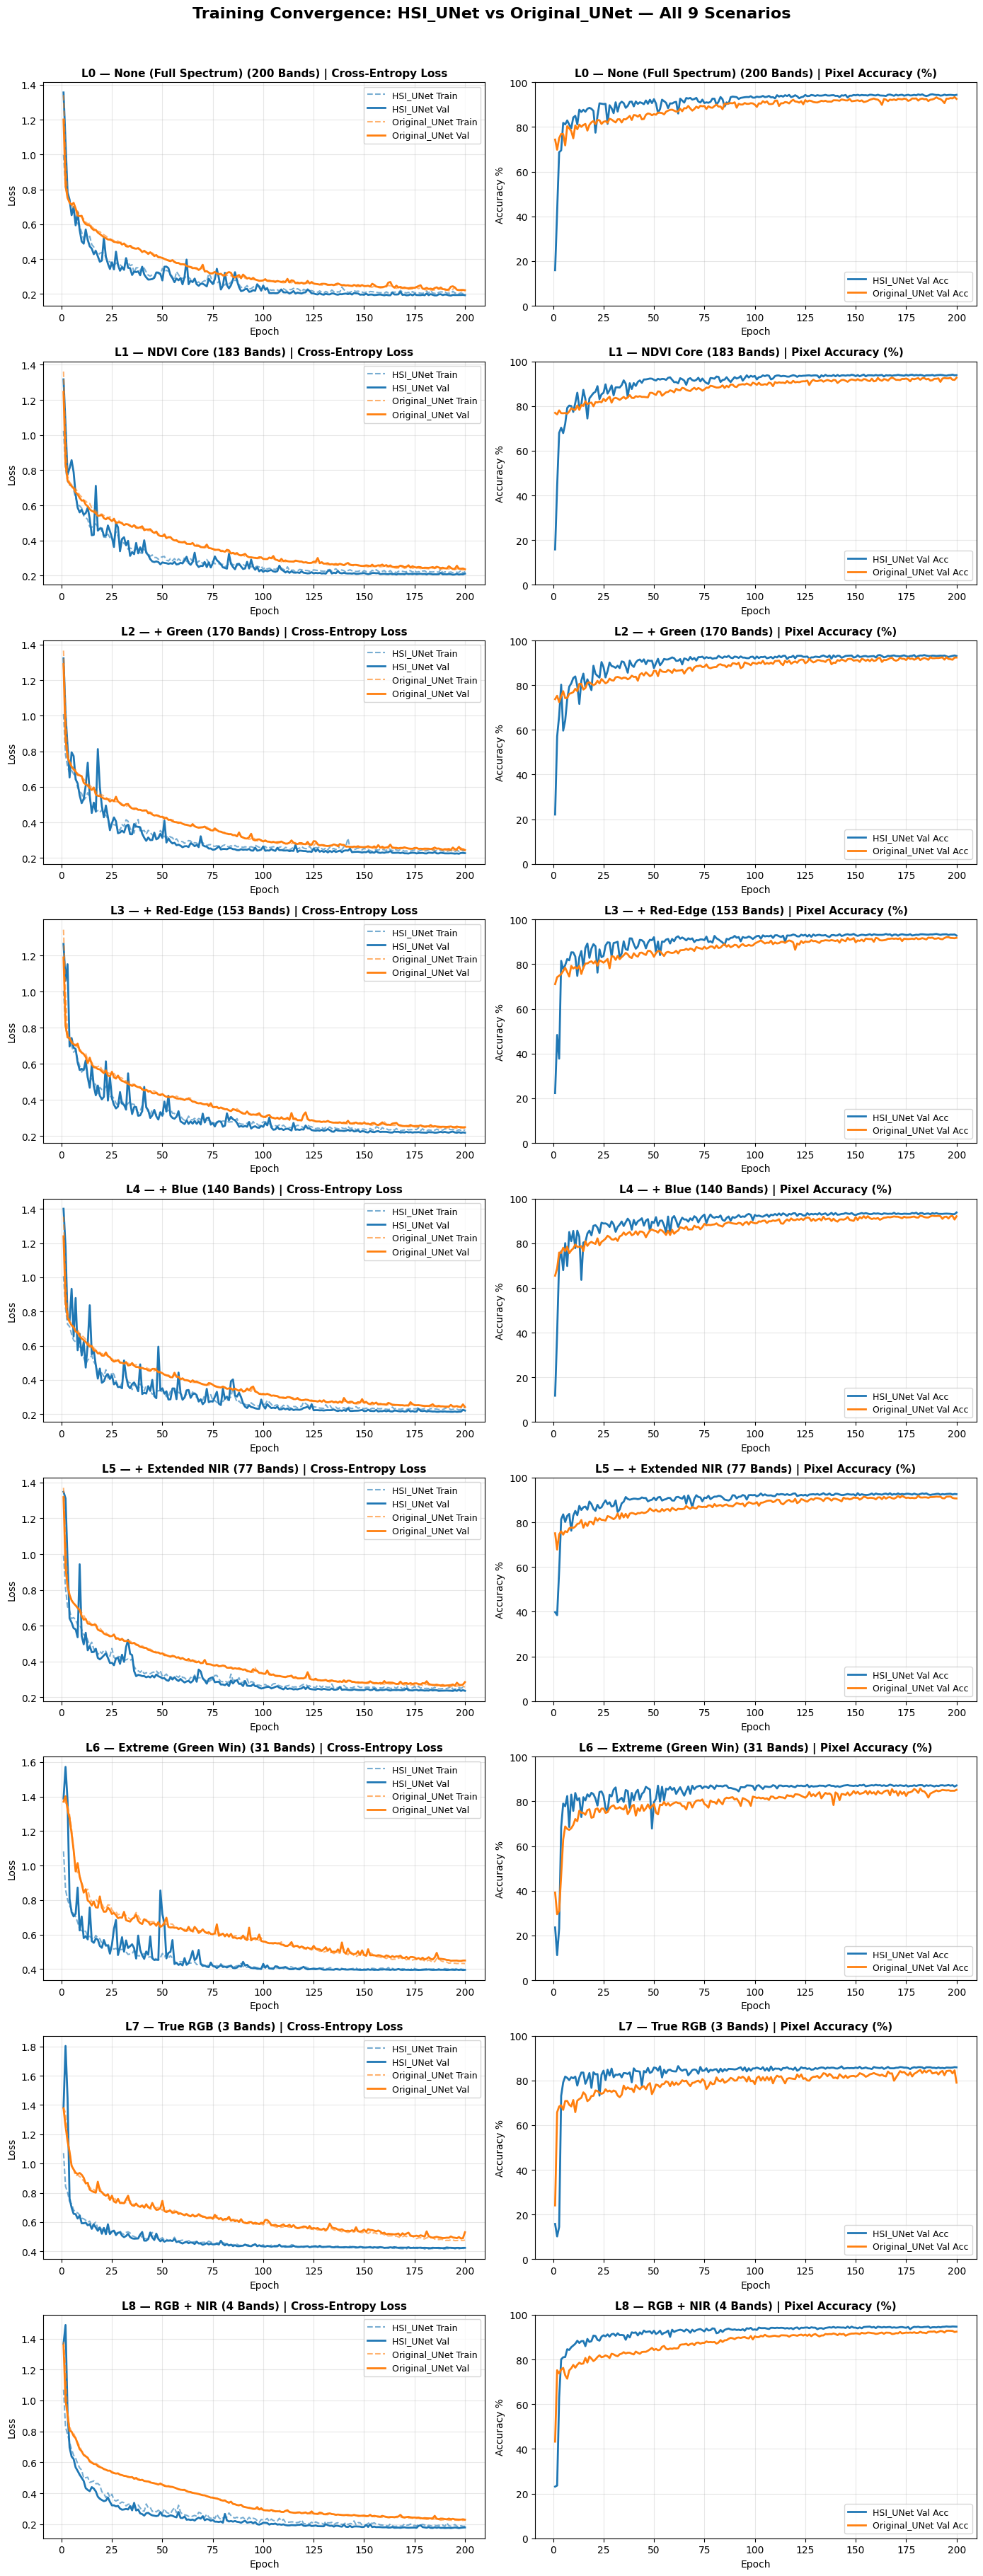

✅ Saved: model_comparison_curves.png


In [2]:
with open('all_run_histories.pkl', 'rb') as f:
    all_run_histories = pickle.load(f)

SCENARIOS = [
    (0, 200, 'None (Full Spectrum)'),
    (1, 183, 'NDVI Core'),
    (2, 170, '+ Green'),
    (3, 153, '+ Red-Edge'),
    (4, 140, '+ Blue'),
    (5,  77, '+ Extended NIR'),
    (6,  31, 'Extreme (Green Win)'),
    (7,   3, 'True RGB'),
    (8,   4, 'RGB + NIR'),
]

MODELS = ["HSI_UNet", "Original_UNet"]
COLORS = {'HSI_UNet': '#1f77b4', 'Original_UNet': '#ff7f0e'}

fig, axes = plt.subplots(len(SCENARIOS), 2, figsize=(14, 4 * len(SCENARIOS)))

for row, (lvl, bands, name) in enumerate(SCENARIOS):
    for model_name in MODELS:
        hist_key = f"{model_name}_L{lvl}"

        if hist_key not in all_run_histories:
            print(f"Missing history for {hist_key}, skipping.")
            continue

        history = all_run_histories[hist_key]
        train_losses = history.get('train_loss', [])
        val_losses   = history.get('val_loss', [])
        val_accs     = history.get('val_acc', [])
        epochs = range(1, len(train_losses) + 1)

        # --- Left Column: Loss ---
        axes[row, 0].plot(epochs, train_losses, color=COLORS[model_name], linestyle='--', alpha=0.6, label=f'{model_name} Train')
        axes[row, 0].plot(epochs, val_losses,   color=COLORS[model_name], linestyle='-',  linewidth=2, label=f'{model_name} Val')

        # --- Right Column: Accuracy ---
        axes[row, 1].plot(epochs, val_accs, color=COLORS[model_name], linewidth=2, label=f'{model_name} Val Acc')

    # Formatting Left (Loss)
    axes[row, 0].set_title(f'L{lvl} — {name} ({bands} Bands) | Cross-Entropy Loss', fontsize=11, fontweight='bold')
    axes[row, 0].set_ylabel('Loss')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 0].legend(fontsize=9, loc='upper right')

    # Formatting Right (Accuracy)
    axes[row, 1].set_title(f'L{lvl} — {name} ({bands} Bands) | Pixel Accuracy (%)', fontsize=11, fontweight='bold')
    axes[row, 1].set_ylabel('Accuracy %')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].set_ylim(0, 100)
    axes[row, 1].grid(True, alpha=0.3)
    axes[row, 1].legend(fontsize=9, loc='lower right')

plt.suptitle('Training Convergence: HSI_UNet vs Original_UNet — All 9 Scenarios',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_curves.png')

with open('all_run_histories.pkl', 'rb') as f:
    all_run_histories = pickle.load(f)

SCENARIOS = [
    (0, 200, 'None (Full Spectrum)'),
    (1, 183, 'NDVI Core'),
    (2, 170, '+ Green'),
    (3, 153, '+ Red-Edge'),
    (4, 140, '+ Blue'),
    (5,  77, '+ Extended NIR'),
    (6,  31, 'Extreme (Green Win)'),
    (7,   3, 'True RGB'),
    (8,   4, 'RGB + NIR'),
]

MODELS = ["HSI_UNet", "Original_UNet"]
COLORS = {'HSI_UNet': '#1f77b4', 'Original_UNet': '#ff7f0e'}

fig, axes = plt.subplots(len(SCENARIOS), 2, figsize=(14, 4 * len(SCENARIOS)))

for row, (lvl, bands, name) in enumerate(SCENARIOS):
    for model_name in MODELS:
        hist_key = f"{model_name}_L{lvl}"

        if hist_key not in all_run_histories:
            print(f"Missing history for {hist_key}, skipping.")
            continue

        history = all_run_histories[hist_key]
        train_losses = history.get('train_loss', [])
        val_losses   = history.get('val_loss', [])
        val_accs     = history.get('val_acc', [])
        epochs = range(1, len(train_losses) + 1)

        # --- Left Column: Loss ---
        axes[row, 0].plot(epochs, train_losses, color=COLORS[model_name], linestyle='--', alpha=0.6, label=f'{model_name} Train')
        axes[row, 0].plot(epochs, val_losses,   color=COLORS[model_name], linestyle='-',  linewidth=2, label=f'{model_name} Val')

        # --- Right Column: Accuracy ---
        axes[row, 1].plot(epochs, val_accs, color=COLORS[model_name], linewidth=2, label=f'{model_name} Val Acc')

    # Formatting Left (Loss)
    axes[row, 0].set_title(f'L{lvl} — {name} ({bands} Bands) | Cross-Entropy Loss', fontsize=11, fontweight='bold')
    axes[row, 0].set_ylabel('Loss')
    axes[row, 0].set_xlabel('Epoch')
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 0].legend(fontsize=9, loc='upper right')

    # Formatting Right (Accuracy)
    axes[row, 1].set_title(f'L{lvl} — {name} ({bands} Bands) | Pixel Accuracy (%)', fontsize=11, fontweight='bold')
    axes[row, 1].set_ylabel('Accuracy %')
    axes[row, 1].set_xlabel('Epoch')
    axes[row, 1].set_ylim(0, 100)
    axes[row, 1].grid(True, alpha=0.3)
    axes[row, 1].legend(fontsize=9, loc='lower right')

plt.suptitle('Training Convergence: HSI_UNet vs Original_UNet — All 9 Scenarios',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_curves.png')

Saved: training_convergence_1.png


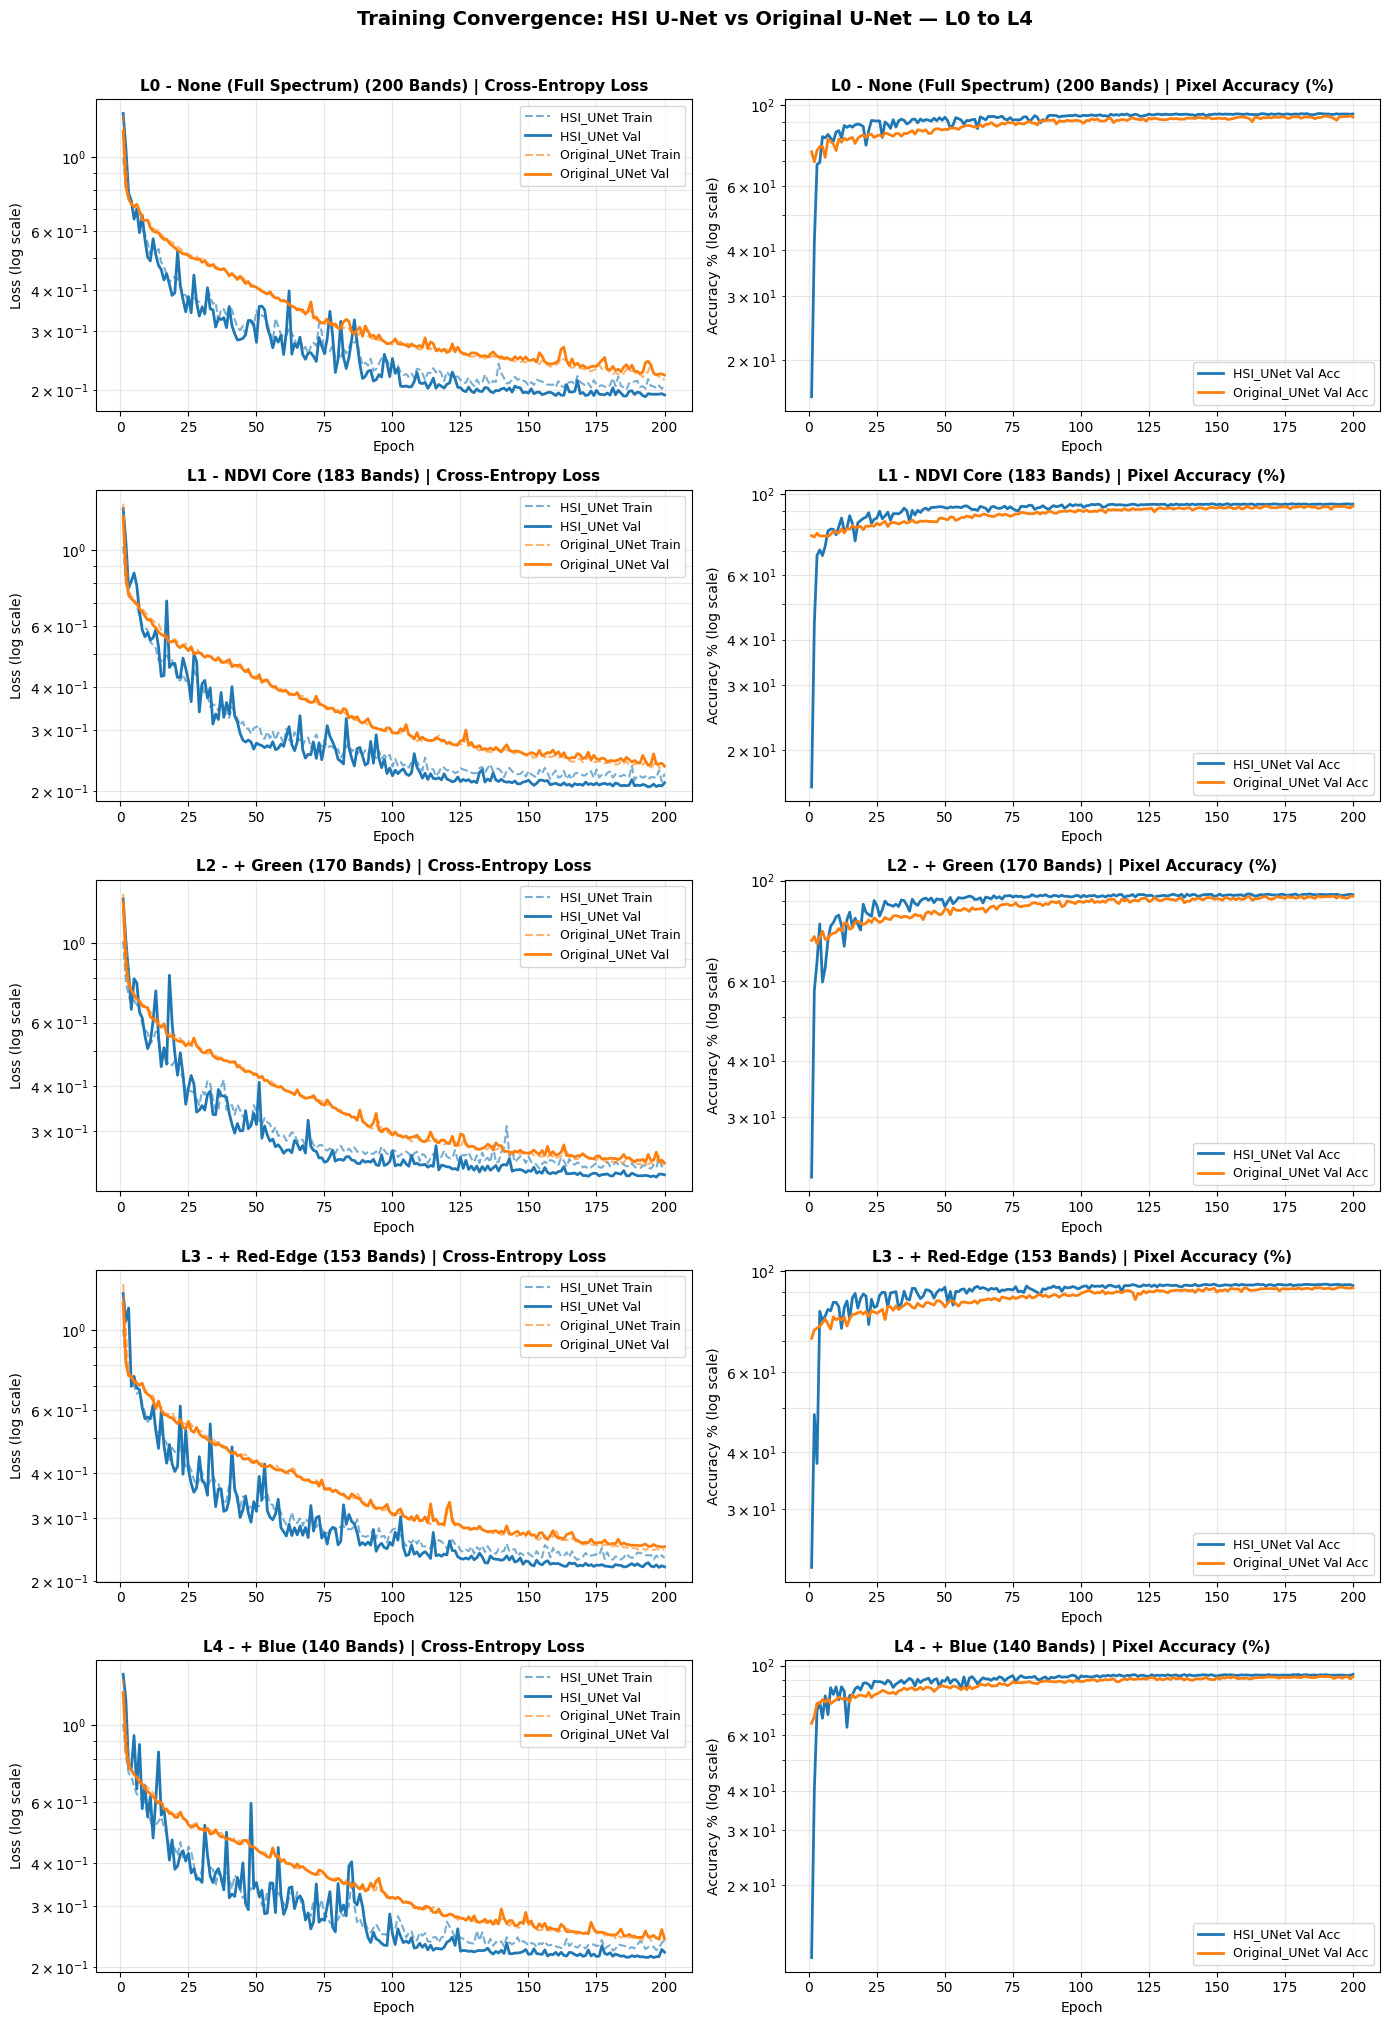

Saved: training_convergence_2.png


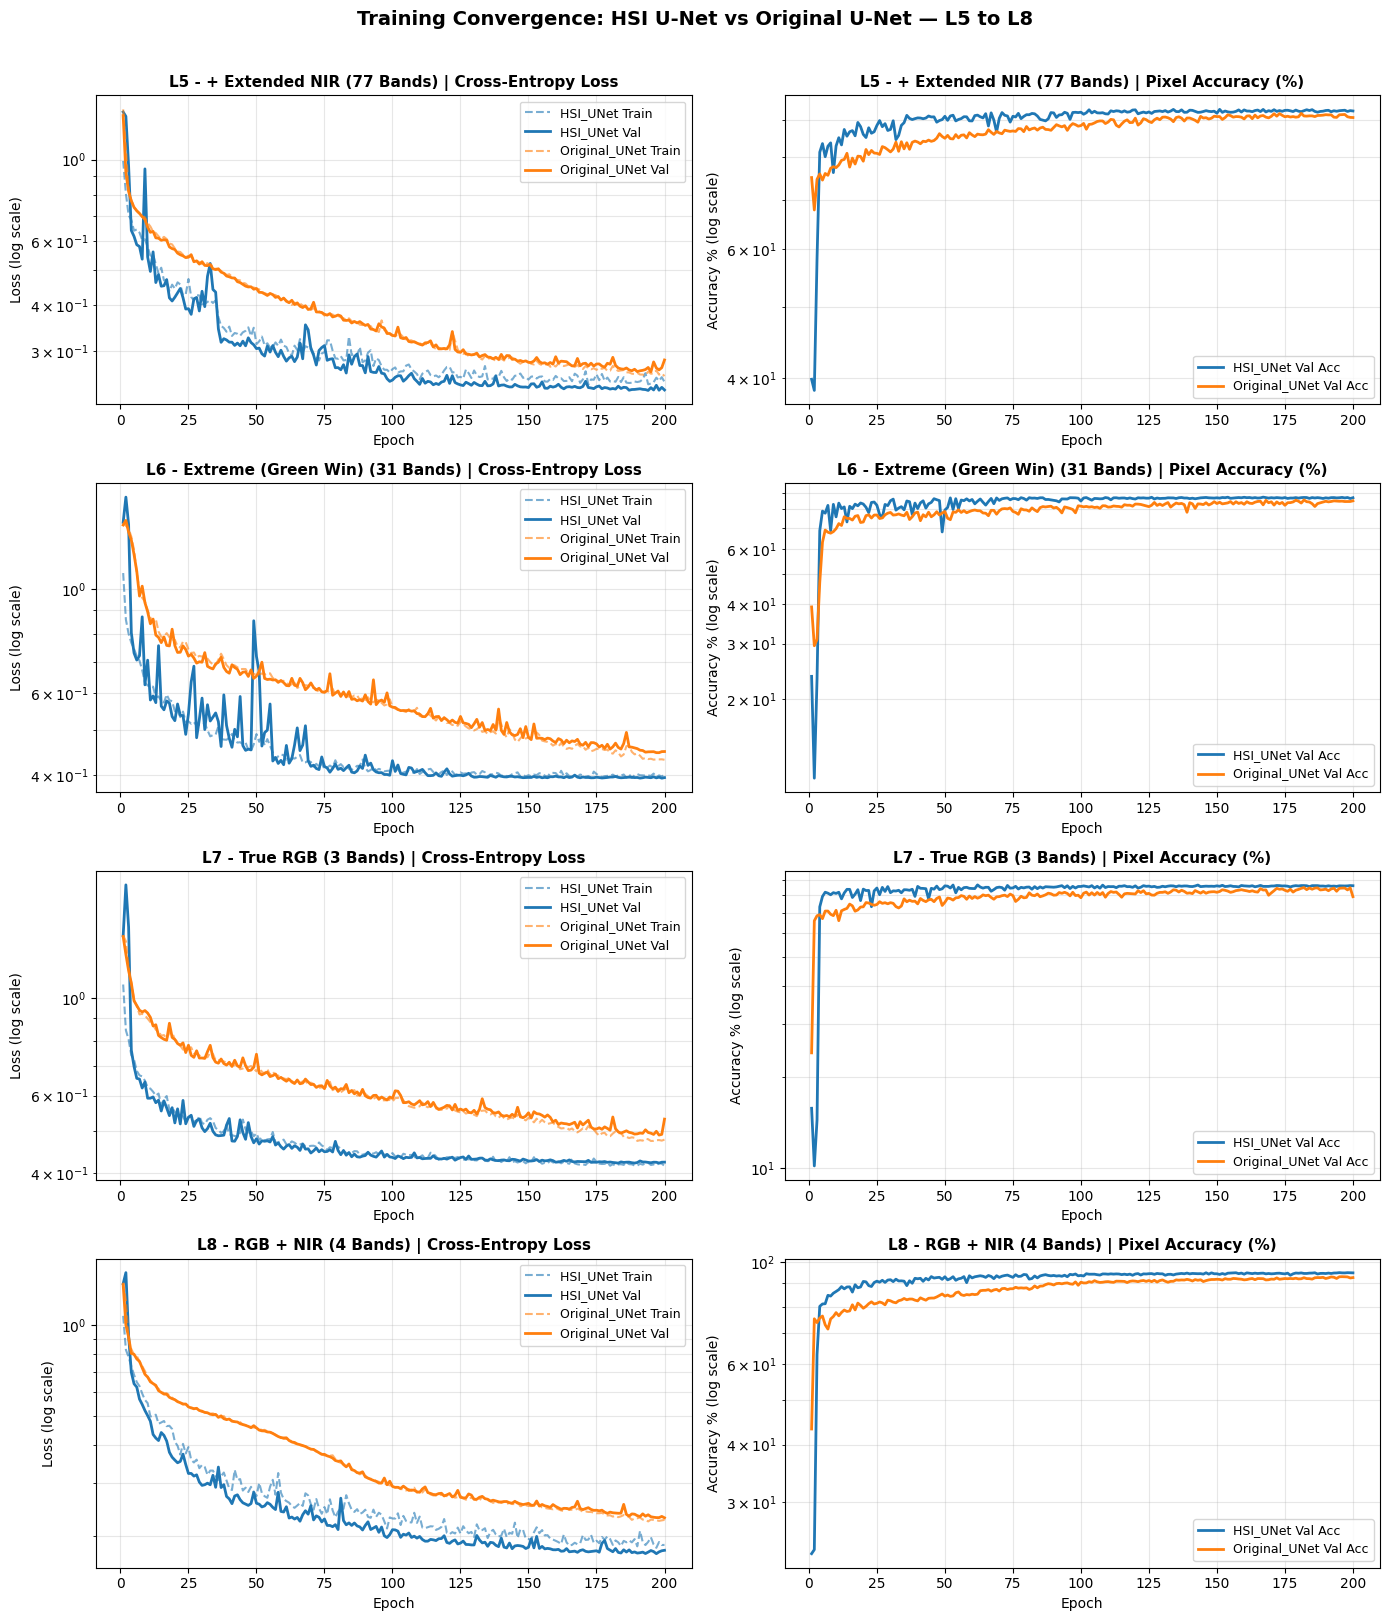

In [5]:
import pickle
import matplotlib.pyplot as plt

with open('all_run_histories.pkl', 'rb') as f:
    all_run_histories = pickle.load(f)

SCENARIOS = [
    (0, 200, 'None (Full Spectrum)'),
    (1, 183, 'NDVI Core'),
    (2, 170, '+ Green'),
    (3, 153, '+ Red-Edge'),
    (4, 140, '+ Blue'),
    (5,  77, '+ Extended NIR'),
    (6,  31, 'Extreme (Green Win)'),
    (7,   3, 'True RGB'),
    (8,   4, 'RGB + NIR'),
]

MODELS = ["HSI_UNet", "Original_UNet"]
COLORS = {'HSI_UNet': '#1f77b4', 'Original_UNet': '#ff7f0e'}

# Split into two groups
SPLIT = [SCENARIOS[:5], SCENARIOS[5:]]
FILENAMES = ['training_convergence_1.png', 'training_convergence_2.png']
TITLES = [
    'Training Convergence: HSI U-Net vs Original U-Net — L0 to L4',
    'Training Convergence: HSI U-Net vs Original U-Net — L5 to L8',
]

for scenarios, filename, title in zip(SPLIT, FILENAMES, TITLES):
    fig, axes = plt.subplots(len(scenarios), 2, figsize=(14, 4 * len(scenarios)))

    for row, (lvl, bands, name) in enumerate(scenarios):
        for model_name in MODELS:
            hist_key = f"{model_name}_L{lvl}"
            if hist_key not in all_run_histories:
                print(f"Missing history for {hist_key}, skipping.")
                continue
            history      = all_run_histories[hist_key]
            train_losses = history.get('train_loss', [])
            val_losses   = history.get('val_loss',   [])
            val_accs     = history.get('val_acc',    [])
            epochs       = range(1, len(train_losses) + 1)

            axes[row, 0].plot(epochs, train_losses, color=COLORS[model_name],
                              linestyle='--', alpha=0.6, label=f'{model_name} Train')
            axes[row, 0].plot(epochs, val_losses,   color=COLORS[model_name],
                              linestyle='-', linewidth=2, label=f'{model_name} Val')
            axes[row, 1].plot(epochs, val_accs, color=COLORS[model_name],
                              linewidth=2, label=f'{model_name} Val Acc')

        axes[row, 0].set_title(f'L{lvl} - {name} ({bands} Bands) | Cross-Entropy Loss',
                               fontsize=11, fontweight='bold')
        axes[row, 0].set_ylabel('Loss (log scale)')
        axes[row, 0].set_xlabel('Epoch')
        axes[row, 0].set_yscale('log')
        axes[row, 0].grid(True, alpha=0.3, which='both')
        axes[row, 0].legend(fontsize=9, loc='upper right')

        axes[row, 1].set_title(f'L{lvl} - {name} ({bands} Bands) | Pixel Accuracy (%)',
                               fontsize=11, fontweight='bold')
        axes[row, 1].set_ylabel('Accuracy % (log scale)')
        axes[row, 1].set_xlabel('Epoch')
        axes[row, 1].set_yscale('log')
        axes[row, 1].grid(True, alpha=0.3, which='both')
        axes[row, 1].legend(fontsize=9, loc='lower right')

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {filename}')
    plt.show()
    plt.close()

Preprocessing full image...
Running Full Inference (Stride 48)...


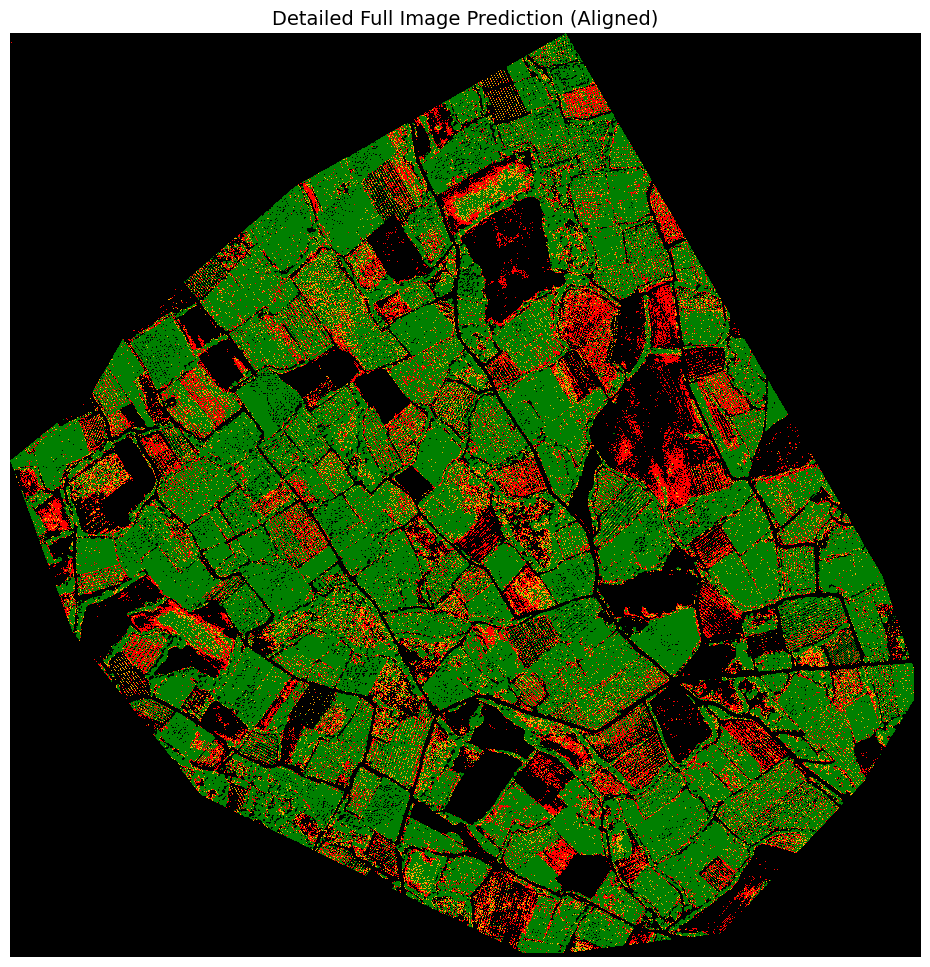

Standalone result saved as 'full_image_standalone_aligned.png'


In [16]:
import tifffile
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import colors

# THE SHARED PREPROCESSING
def build_4band_image(ortho_path, ndvi_path):
    """Stacks RGB + NIR into a 4-band image, ignoring background pixels when normalizing."""
    # Load RGB
    ortho = tifffile.imread(ortho_path).astype(np.float32)
    if ortho.ndim == 3 and ortho.shape[0] < ortho.shape[2]:
        ortho = np.transpose(ortho, (1, 2, 0))
    if ortho.shape[2] == 4:
        ortho = ortho[:, :, :3]
    ortho = ortho / 255.0

    # Normalize RGB (Ignoring background pixels > 0)
    for c in range(3):
        ch = ortho[:, :, c]
        valid = ch > 0 
        if np.any(valid):
            p2, p98 = np.percentile(ch[valid], [2, 98])
            ortho[:, :, c] = np.clip((ch - p2) / (p98 - p2 + 1e-8), 0, 1)

    # Load NDVI → NIR Proxy (Green channel)
    ndvi_raw = tifffile.imread(ndvi_path).astype(np.float32)
    if ndvi_raw.ndim == 3 and ndvi_raw.shape[0] < ndvi_raw.shape[2]:
        ndvi_raw = np.transpose(ndvi_raw, (1, 2, 0))
    
    nir_proxy = ndvi_raw[:, :, 1] / 255.0
    valid_nir = nir_proxy > 0
    if np.any(valid_nir):
        n2, n98 = np.percentile(nir_proxy[valid_nir], [2, 98])
        nir_proxy = np.clip((nir_proxy - n2) / (n98 - n2 + 1e-8), 0, 1)

    return np.concatenate([ortho, nir_proxy[:, :, np.newaxis]], axis=2)

# MATCHING SLIDING WINDOW INFERENCE
def sliding_window_inference(image, model, device, patch_size=96, stride=48):
    """Sliding-window inference over a full image, averaging softmax outputs across overlaps."""
    H, W, C = image.shape
    num_classes = 4
    prob_map = np.zeros((H, W, num_classes), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    model.eval()
    with torch.no_grad():
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                patch = np.nan_to_num(image[y:y+patch_size, x:x+patch_size, :])
                tensor = torch.from_numpy(patch).permute(2, 0, 1).unsqueeze(0).to(device)
                
                outputs = model(tensor)
                # Use softmax to handle overlaps correctly
                probs = torch.softmax(outputs, dim=1).squeeze(0).permute(1, 2, 0).cpu().numpy()
                
                prob_map[y:y+patch_size, x:x+patch_size, :] += probs
                count_map[y:y+patch_size, x:x+patch_size] += 1

    # Final pixel class determination
    avg_probs = prob_map / np.maximum(count_map[:, :, np.newaxis], 1)
    return np.argmax(avg_probs, axis=2).astype(np.uint8)

# EXECUTION FOR FULL IMAGE
# Set paths for your full mosaic
ORTHO_PATH = r'C:\Users\Achilleas\Desktop\DataToTest\1.tif'
NDVI_PATH  = r'C:\Users\Achilleas\Desktop\DataToTest\1_1.tif'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model
state_dict = torch.load('BEST_MODEL_HSI_UNet_L8.pth', map_location=DEVICE)
model = HSI_UNet(in_channels=4, num_classes=4).to(DEVICE)
model.load_state_dict(state_dict)
model.eval()

print("Preprocessing full image...")
full_4band = build_4band_image(ORTHO_PATH, NDVI_PATH)

print("Running Full Inference (Stride 48)...")
final_mask = sliding_window_inference(full_4band, model, DEVICE, patch_size=96, stride=48)

# VISUALIZATION
cmap = colors.ListedColormap(['black', 'red', 'orange', 'green'])
norm = colors.BoundaryNorm(np.arange(-0.5, 4, 1), cmap.N)

plt.figure(figsize=(12, 12))
# Use nearest interpolation to ensure the "beautiful" granular detail is sharp
plt.imshow(final_mask, cmap=cmap, norm=norm, interpolation='nearest')
plt.title("Detailed Full Image Prediction (Aligned)", fontsize=14)
plt.axis('off')

# Save result
plt.savefig('full_image_standalone_aligned.png', dpi=300, bbox_inches='tight')
plt.show()

print("Standalone result saved as 'full_image_standalone_aligned.png'")

Processing Season 1...
Processing Season 2...
Processing Season 3...


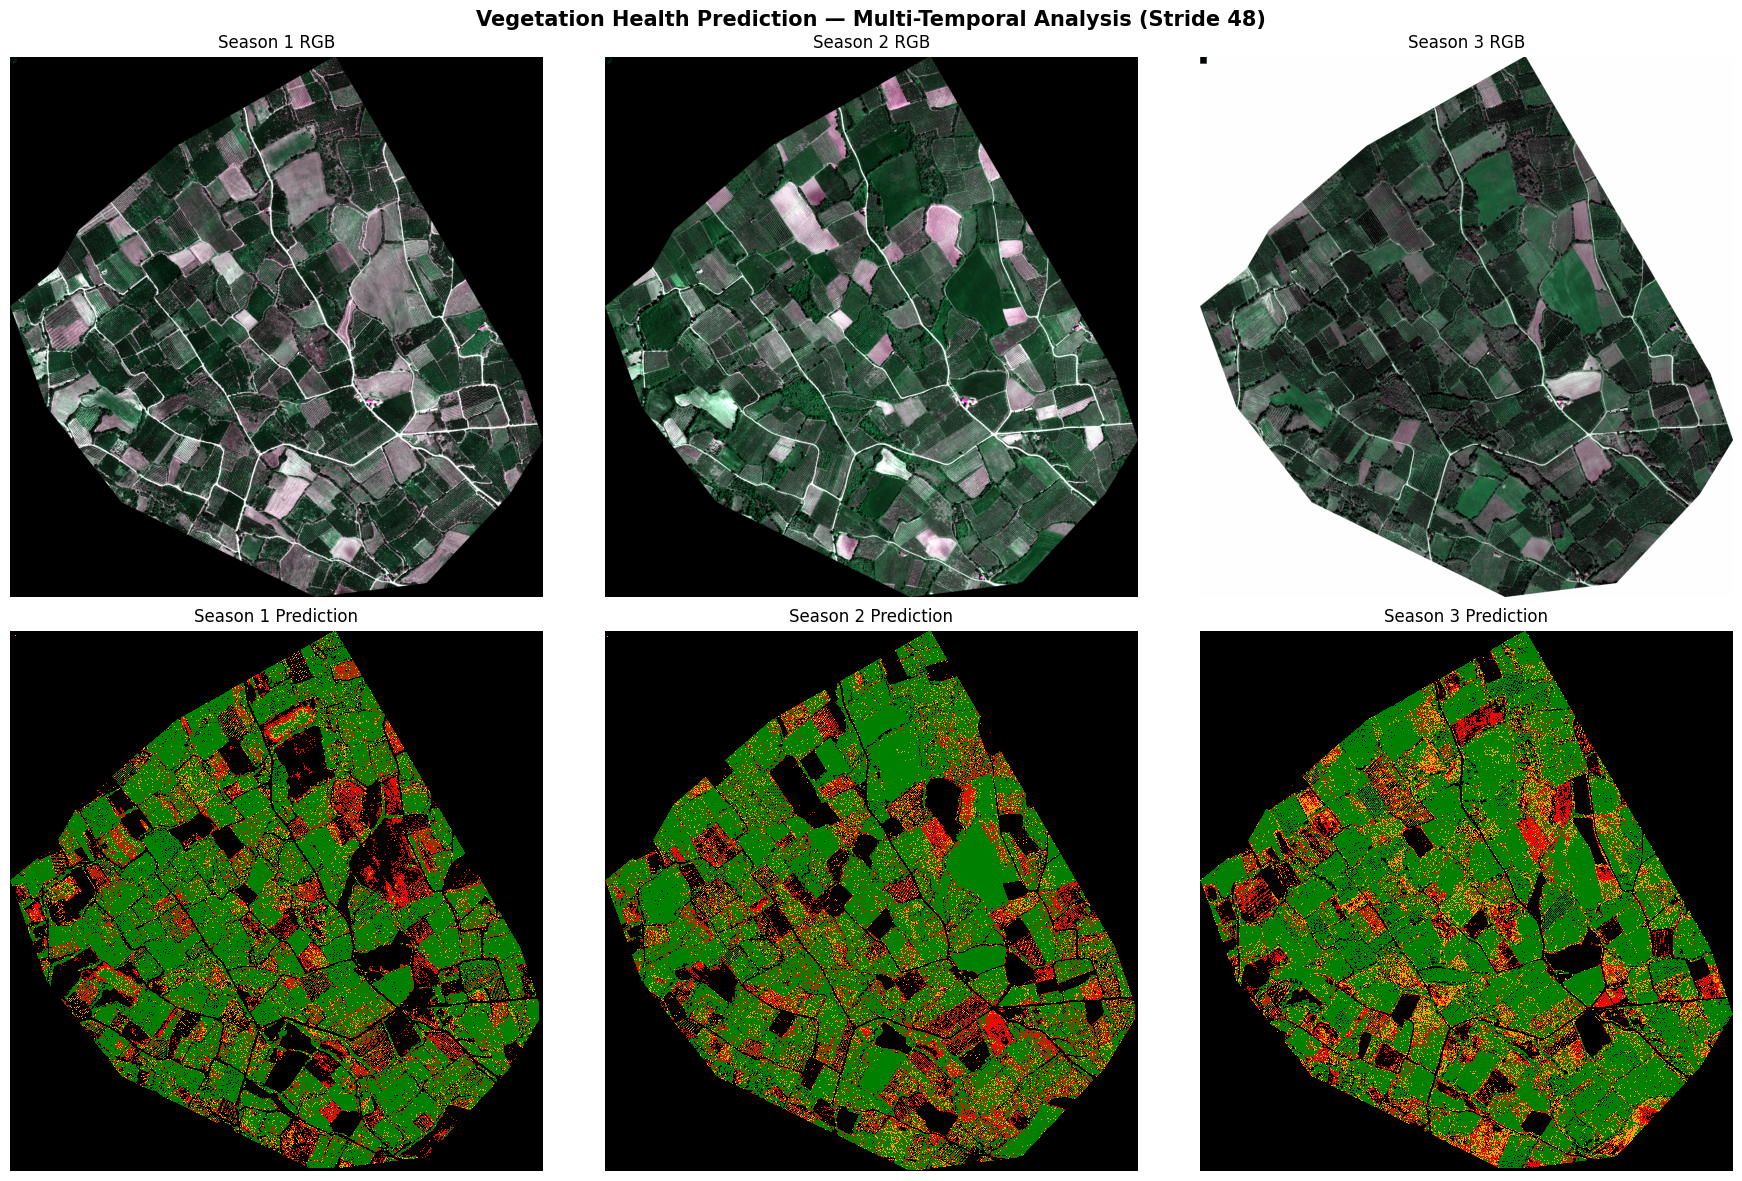

In [15]:
import tifffile
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import colors

# STANDARDIZED PREPROCESSING
def build_4band_image(ortho_path, ndvi_path):
    """Stacks RGB + NIR into a 4-band image. Kept identical across scripts so results line up."""
    ortho = tifffile.imread(ortho_path).astype(np.float32)
    if ortho.ndim == 3 and ortho.shape[0] < ortho.shape[2]:
        ortho = np.transpose(ortho, (1, 2, 0))
    if ortho.shape[2] == 4:
        ortho = ortho[:, :, :3]
    ortho = ortho / 255.0

    # Normalize RGB (Ignoring background)
    for c in range(3):
        ch = ortho[:, :, c]
        valid = ch > 0 
        if np.any(valid):
            p2, p98 = np.percentile(ch[valid], [2, 98])
            ortho[:, :, c] = np.clip((ch - p2) / (p98 - p2 + 1e-8), 0, 1)

    # Load NDVI → NIR Proxy
    ndvi_raw = tifffile.imread(ndvi_path).astype(np.float32)
    if ndvi_raw.ndim == 3 and ndvi_raw.shape[0] < ndvi_raw.shape[2]:
        ndvi_raw = np.transpose(ndvi_raw, (1, 2, 0))
    
    nir_proxy = ndvi_raw[:, :, 1] / 255.0
    valid_nir = nir_proxy > 0
    if np.any(valid_nir):
        n2, n98 = np.percentile(nir_proxy[valid_nir], [2, 98])
        nir_proxy = np.clip((nir_proxy - n2) / (n98 - n2 + 1e-8), 0, 1)

    return np.concatenate([ortho, nir_proxy[:, :, np.newaxis]], axis=2)

# MATCHING SLIDING WINDOW INFERENCE
def sliding_window_inference(image, model, device, patch_size=96, stride=48):
    """Same sliding-window inference loop, stride 48, kept consistent with the full-image version."""
    H, W, C = image.shape
    num_classes = 4
    prob_map = np.zeros((H, W, num_classes), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    model.eval()
    with torch.no_grad():
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                patch = np.nan_to_num(image[y:y+patch_size, x:x+patch_size, :])
                tensor = torch.from_numpy(patch).permute(2, 0, 1).unsqueeze(0).to(device)
                
                outputs = model(tensor)
                # We use softmax to ensure we handle the 'voting' correctly
                probs = torch.softmax(outputs, dim=1).squeeze(0).permute(1, 2, 0).cpu().numpy()
                
                prob_map[y:y+patch_size, x:x+patch_size, :] += probs
                count_map[y:y+patch_size, x:x+patch_size] += 1

    # Final pixel class determination
    avg_probs = prob_map / np.maximum(count_map[:, :, np.newaxis], 1)
    return np.argmax(avg_probs, axis=2).astype(np.uint8)

# MAIN EXECUTION
# (Ensure DEVICE and HSI_UNet class are already defined)

seasons = [
    {'ortho': r'C:\Users\Achilleas\Desktop\DataToTest\1.tif', 'ndvi': r'C:\Users\Achilleas\Desktop\DataToTest\1_1.tif', 'label': 'Season 1'},
    {'ortho': r'C:\Users\Achilleas\Desktop\DataToTest\2.tif', 'ndvi': r'C:\Users\Achilleas\Desktop\DataToTest\2_2.tif', 'label': 'Season 2'},
    {'ortho': r'C:\Users\Achilleas\Desktop\DataToTest\3.tif', 'ndvi': r'C:\Users\Achilleas\Desktop\DataToTest\3_3.tif', 'label': 'Season 3'},
]

# Style settings
cmap = colors.ListedColormap(['black', 'red', 'orange', 'green'])
norm = colors.BoundaryNorm(np.arange(-0.5, 4, 1), cmap.N)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Vegetation Health Prediction — Multi-Temporal Analysis (Stride 48)', fontsize=15, fontweight='bold')

for i, season in enumerate(seasons):
    print(f"Processing {season['label']}...")
    img_4band = build_4band_image(season['ortho'], season['ndvi'])
    
    # RUN WITH STRIDE 48
    pred = sliding_window_inference(img_4band, model, DEVICE, patch_size=96, stride=48)

    # RGB Visualization
    rgb = img_4band[:, :, :3]
    rgb_vis = np.clip((rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8), 0, 1)

    axes[0, i].imshow(rgb_vis)
    axes[0, i].set_title(f'{season["label"]} RGB')
    axes[0, i].axis('off')

    # Health Map
    axes[1, i].imshow(pred, cmap=cmap, norm=norm, interpolation='nearest')
    axes[1, i].set_title(f'{season["label"]} Prediction')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('seasonal_match_stride48.png', dpi=250)
plt.show()